# 📊 Sales Forecasting Across Multiple Retail Stores
### --> NextHikes IT Solutions
### --> Project: Rossmann Pharmaceuticals
### --> Prepared by: Ankita Vaghela


# **Import Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging
# from google.colab import files

### **Logger Setup**

In [3]:
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)
logger.propagate = False

if not logger.handlers:
    console_handler = logging.StreamHandler()
    file_handler = logging.FileHandler('Project6_store_train.log')
    formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')

    console_handler.setFormatter(formatter)
    file_handler.setFormatter(formatter)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)

logger.info("Project6_store_train initialized and Logger set up successfully.")

2026-09-14 15:33:19,505 - INFO - Project6_store_train initialized and Logger set up successfully.


#### **Insights:**
- This cell initializes a Python `logging` object named `logger`.
- It sets the logging level to `DEBUG`, meaning all messages (DEBUG, INFO, WARNING, ERROR, CRITICAL) will be processed.
- It configures both a `StreamHandler` (to print logs to the console) and a `FileHandler` (to save logs to 'Project6_store_train.log').
- A formatter is applied to both handlers to ensure log messages include timestamp, level, and message content.
- This setup ensures that all important steps and potential issues during the notebook execution are logged for tracking and debugging.

# **Preprocessing for Store_Train Dataset**

### **Data Loading**

In [4]:
logger.info("Loading store_train dataset")
s_train = pd.read_csv("store_train.csv",low_memory=False)
s_test = pd.read_csv("store_test.csv",low_memory=False)

2026-09-14 15:33:22,008 - INFO - Loading store_train dataset


#### **Insights:**
- The `logger.info()` call confirms the action of loading datasets.
- `pd.read_csv()` is used to load two CSV files, 'store_train.csv' and 'store_test.csv', into pandas DataFrames `s_train` and `s_test` respectively.
- `low_memory=False` is specified to ensure proper type inference for large files, preventing potential mixed-type warnings.

In [5]:
s_train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9,2008,0,22,2012,"Jan,Apr,Jul,Oct"
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9,2009,0,22,2012,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4,2015,0,22,2012,NaN


#### **Insights:**
- Displays the first 5 rows of the `s_train` DataFrame.
- This provides a quick overview of the dataset's structure, column names, and initial data values.
- Key columns like 'Store', 'Date', 'Sales', 'Customers', 'StoreType', and various promotion/competition-related features are visible.

In [6]:
s_train.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6,2014,1,31,2013,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4,2006,0,22,2012,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,8,2010,0,22,2012,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,8,2010,0,22,2012,NaN
1017208,1115,2,2013-01-01,0,0,0,0,a,1,d,c,5350.0,8,2010,1,22,2012,"Mar,Jun,Sept,Dec"


#### **Insights:**
- Displays the last 5 rows of the `s_train` DataFrame.
- This helps in understanding the range of data, especially for time-series data, confirming the earliest entries if sorted by date, or simply showing the end of the loaded data.

In [7]:
s_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  str    
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1017209 non-null  float64
 12  CompetitionOpenSinceMonth  1017209 non-null  int64  
 13  CompetitionOpenSinceYea

#### **Insights:**
- Provides a concise summary of the DataFrame: number of entries, column names, non-null counts, data types (`Dtype`), and memory usage.
- **Key Observations:**
    - `Date` is an `object` type, which needs to be converted to `datetime`.
    - `CompetitionDistance` is `float64`.
    - `PromoInterval` has significantly fewer non-null entries (510120 out of 1017209), indicating a large number of missing values.
    - `StateHoliday` is an `object` type, which also needs closer inspection due to potential mixed types (e.g., '0' and '0.0').
- This output is crucial for identifying columns that require type conversion or missing value imputation.

In [8]:
s_train.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.422021e+03,7.469899e+00,2.009107e+03,5.005638e-01,2.263526e+01,2.011876e+03
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.706918e+03,2.677243e+00,4.986802e+00,4.999999e-01,9.993137e+00,1.182965e+00
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000e+00,1.900000e+03,0.000000e+00,1.000000e+00,2.009000e+03
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,6.000000e+00,2.008000e+03,0.000000e+00,2.200000e+01,2.012000e+03
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.325000e+03,8.000000e+00,2.010000e+03,1.000000e+00,2.200000e+01,2.012000e+03
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.880000e+03,9.000000e+00,2.011000e+03,1.000000e+00,2.200000e+01,2.012000e+03
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,1.200000e+01,2.015000e+03,1.000000e+00,5.000000e+01,2.015000e+03


#### **Insights:**
- Generates descriptive statistics for numerical columns in `s_train`.
- Provides count, mean, standard deviation, min, 25th percentile (Q1), 50th percentile (median), 75th percentile (Q3), and max values.
- **Key Observations:**
    - `Sales` and `Customers` have a minimum of 0, indicating closed stores or days with no sales/customers.
    - `CompetitionDistance` ranges from 20 to 75860, suggesting a wide variation in store proximity to competitors.
    - `Promo` and `SchoolHoliday` are binary (0/1) indicators.
    - `Open` column: the mean (0.83) suggests that stores are open on most days.
- This helps in understanding the central tendency, spread, and potential range of numerical features, aiding in outlier detection and feature scaling decisions.

### **Fixing Data Type**

In [9]:
s_train['Date'] = pd.to_datetime(s_train['Date'])
s_train['StateHoliday'] = s_train['StateHoliday'].astype(str)
s_train['StateHoliday'] = s_train['StateHoliday'].replace('0.0', '0')

#### **Insights:**
- Converts the `Date` column to datetime objects using `pd.to_datetime()`, which is essential for time-series analysis and extracting date-based features.
- Converts `StateHoliday` to string type to ensure consistent handling of categorical values.
- Replaces string '0.0' with '0' in `StateHoliday` to normalize holiday representation, making it consistent with other non-holiday entries, which is a common data cleaning step for categorical variables that might have mixed representations.

### **Check Missing Value**

In [10]:
s_train.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance               0
CompetitionOpenSinceMonth         0
CompetitionOpenSinceYear          0
Promo2                            0
Promo2SinceWeek                   0
Promo2SinceYear                   0
PromoInterval                507089
dtype: int64

#### **Insights:**
- This cell calculates and displays the count of missing values for each column in the `s_train` DataFrame.
- **Key Observation:** `PromoInterval` has `507089` missing values, which is about half of the total rows.
- All other columns have 0 missing values, confirming that `CompetitionDistance` and other `CompetitionOpenSince...` columns were implicitly handled or had no missing values after the previous steps.

### **Handle Missing Value**

In [11]:
s_train['PromoInterval'] = s_train['PromoInterval'].fillna("NoPromo")


#### **Insights:**
- Fills the `NaN` values in the `PromoInterval` column with the string "NoPromo".
- This approach is suitable because `PromoInterval` indicates when promotions are running; thus, a missing value likely means there is no ongoing promotion or the store doesn't participate in Promo2, making "NoPromo" a logical replacement.
- This ensures that all rows have a value for `PromoInterval`, which is important for further analysis or encoding.

### **Check Duplicate Value**

In [12]:
s_train.duplicated().sum()

np.int64(0)

#### **Insights:**
- Checks for any duplicate rows across all columns in the `s_train` DataFrame.
- The output `np.int64(0)` indicates that there are no perfectly identical rows in the dataset.
- This is a good finding as duplicate rows can skew analysis and model training, and their absence means no further action is needed for row-wise duplication.

### **Check Outliers**

In [13]:
def check_outliers_iqr(df):
    numeric_cols = ['Sales', 'Customers', 'CompetitionDistance', 'Promo2SinceWeek', 'Promo2SinceYear', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        print(f"Column: {col}")
        print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
        print(f"Outlier Count: {len(outliers)} ({(len(outliers)/len(df))*100:.2f}%)\n")

check_outliers_iqr(s_train)


Column: Sales
Lower Bound: -2466.50, Upper Bound: 14049.50
Outlier Count: 26694 (2.62%)

Column: Customers
Lower Bound: -243.00, Upper Bound: 1485.00
Outlier Count: 38095 (3.75%)

Column: CompetitionDistance
Lower Bound: -8545.00, Upper Bound: 16135.00
Outlier Count: 99160 (9.75%)

Column: Promo2SinceWeek
Lower Bound: 22.00, Upper Bound: 22.00
Outlier Count: 480484 (47.24%)

Column: Promo2SinceYear
Lower Bound: 2012.00, Upper Bound: 2012.00
Outlier Count: 436004 (42.86%)

Column: CompetitionOpenSinceMonth
Lower Bound: 1.50, Upper Bound: 13.50
Outlier Count: 12452 (1.22%)

Column: CompetitionOpenSinceYear
Lower Bound: 2003.50, Upper Bound: 2015.50
Outlier Count: 83904 (8.25%)



#### **Insights:**
- Defines a function `check_outliers_iqr` that iterates through specified numerical columns.
- For each column, it calculates the first quartile (Q1), third quartile (Q3), and Interquartile Range (IQR).
- It then determines the lower and upper bounds (Q1 - 1.5*IQR, Q3 + 1.5*IQR) to identify outliers.
- The function prints the bounds, the count of outliers, and their percentage relative to the total dataset.
- **Key Observations from Output:**
    - `Promo2SinceWeek` and `Promo2SinceYear` show a very high percentage of outliers (47.24% and 42.86% respectively), suggesting these might be categorical or highly skewed rather than purely continuous numerical data points where IQR-based outlier detection is optimal.
    - `CompetitionDistance` also has a notable percentage of outliers (9.75%).
    - `Sales` and `Customers` have a moderate percentage of outliers (2.62% and 3.75%).

### **Handle Outliers**

In [14]:
def handle_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower_bound, upper_bound)
    return df

for col in ['Sales', 'Customers', 'CompetitionDistance']:
    s_train = handle_outliers_iqr(s_train, col)


#### **Insights:**
- Defines `handle_outliers_iqr` function which uses the IQR method to define lower and upper bounds.
- It then `clip()`s the values in the specified column, meaning any value below the lower bound is set to the lower bound, and any value above the upper bound is set to the upper bound.
- This cell applies this function to 'Sales', 'Customers', and 'CompetitionDistance'.
- **Impact:** This method effectively caps extreme values, reducing their influence on statistical models without removing data points. It is a common technique to handle outliers when removal is not desired, especially for skewed distributions or when the 'outliers' might contain valuable information within a reasonable range.

In [15]:
logger.info("Preprocessing Completed for store_train dataset")

2026-09-14 15:33:37,254 - INFO - Preprocessing Completed for store_train dataset


#### **Insights:**
- This log statement confirms that the preprocessing steps for the `s_train` dataset have been completed.
- It's a useful marker in the log file to track the progress of the data pipeline.

# **Basic Feature Engineering**

In [16]:
s_train['year'] = s_train['Date'].dt.year
s_train['month'] = s_train['Date'].dt.month
s_train['day'] = s_train['Date'].dt.day
s_train['day_of_week'] = s_train['Date'].dt.dayofweek

s_train['sales_per_customer'] = s_train['Sales']/s_train['Customers']

s_train['StateHoliday'] = s_train['StateHoliday'].replace('0', 'No Holiday')
s_train['StateHoliday'] = s_train['StateHoliday'].replace('a', 'Public Holiday')
s_train['StateHoliday'] = s_train['StateHoliday'].replace('b', 'Easter')
s_train['StateHoliday'] = s_train['StateHoliday'].replace('c', 'Christmas')

s_train['Assortment'] = s_train['Assortment'].replace('a', 'Basic')
s_train['Assortment'] = s_train['Assortment'].replace('b', 'Extra')
s_train['Assortment'] = s_train['Assortment'].replace('c', 'Extended')

s_train['StoreType'] = s_train['StoreType'].replace('a', 'store_A')
s_train['StoreType'] = s_train['StoreType'].replace('b', 'store_B')
s_train['StoreType'] = s_train['StoreType'].replace('c', 'store_C')
s_train['StoreType'] = s_train['StoreType'].replace('d', 'store_D')



#### **Insights:**
- **Date Feature Extraction:** Extracts `year`, `month`, `day`, and `day_of_week` from the `Date` column. These are crucial for time-series analysis and identifying temporal patterns.
- **Sales Per Customer:** Creates a new feature `sales_per_customer` by dividing `Sales` by `Customers`. This metric can indicate efficiency or average transaction value.
- **Categorical Feature Renaming:** Renames values in `StateHoliday`, `Assortment`, and `StoreType` columns to more descriptive, human-readable strings (e.g., '0' to 'No Holiday', 'a' to 'Basic', 'a' to 'store_A'). This improves interpretability and readability of the data and subsequent analysis/visualizations.

#### **Create new feature**

In [17]:

def check_promo2(row):
    if row['Promo2'] == 1 and row['Promo2SinceYear'] > 0 and row['Promo2SinceWeek'] > 0:
        return 1
    return 0


s_train['Is_Promo2_Active'] = s_train.apply(check_promo2, axis=1)


#### **Insights:**
- Defines a helper function `check_promo2` which returns 1 if `Promo2` is active (i.e., `Promo2` is 1 and `Promo2SinceYear` and `Promo2SinceWeek` are valid positive values), else 0.
- Applies this function to create a new binary feature `Is_Promo2_Active`.
- This consolidates multiple related `Promo2` features into a single indicator, simplifying analysis and potentially capturing the overall active status of a secondary promotion more directly.

#### **Create new feature**

In [18]:

def calc_competition_open_months(row):

    if pd.isna(row['CompetitionOpenSinceYear']) or pd.isna(row['CompetitionOpenSinceMonth']) or row['CompetitionOpenSinceYear'] == 0:
        return 0

    months = (row['year'] - row['CompetitionOpenSinceYear']) * 12 + (row['month'] - row['CompetitionOpenSinceMonth'])
    return max(0, months)

s_train['CompetitionOpenMonths'] = s_train.apply(calc_competition_open_months, axis=1)



#### **Insights:**
- Defines `calc_competition_open_months` to calculate how many months a competitor has been open relative to the current sale date.
- It handles cases where `CompetitionOpenSinceYear` or `CompetitionOpenSinceMonth` might be missing or invalid by returning 0.
- The calculation considers the difference in years and months.
- Creates `CompetitionOpenMonths` feature, providing a continuous numerical representation of competitive pressure duration, which could be an important factor influencing sales.

In [19]:
# 1. Weekend Feature (1 = Weekend, 0 = Weekday)
s_train["is_weekend"] = s_train["day_of_week"].apply(
    lambda x: 1 if x >= 5 else 0
)

# 2. Month Period (0 = Start, 1 = Mid, 2 = End)
s_train["month_period"] = s_train["day"].apply(
    lambda x: 0 if x <= 10 else (1 if x <= 20 else 2)
)

# 3. Month Start / Month End / Quarter
s_train["is_month_start"] = s_train["Date"].dt.is_month_start.astype(int)
s_train["is_month_end"] = s_train["Date"].dt.is_month_end.astype(int)
s_train["quarter"] = s_train["Date"].dt.quarter

logger.info("Basic date features added successfully")

2026-09-14 15:35:15,027 - INFO - Basic date features added successfully


#### **Insights:**
- **`is_weekend`**: Creates a binary feature indicating whether a day is a weekend (Saturday or Sunday).
- **`month_period`**: Categorizes days within a month into three periods (start, mid, end), potentially capturing sales patterns related to salary days or billing cycles.
- **`is_month_start` / `is_month_end`**: Binary flags for the first and last day of the month, which often have distinct sales behaviors.
- **`quarter`**: Extracts the fiscal quarter from the date, useful for identifying seasonal trends.
- These features enrich the dataset with more granular temporal information, allowing models to learn from day-specific, weekly, monthly, and quarterly patterns.

In [20]:
logger.info("Feature Engineering Completed")

2026-09-14 15:35:22,940 - INFO - Feature Engineering Completed


#### **Insights:**
- This log statement indicates that all feature engineering tasks have been successfully completed.
- It serves as a checkpoint in the data preparation workflow.

# **Exploratory Data Analysis**

## **Univariate Analysis**

## *Numerical Column*

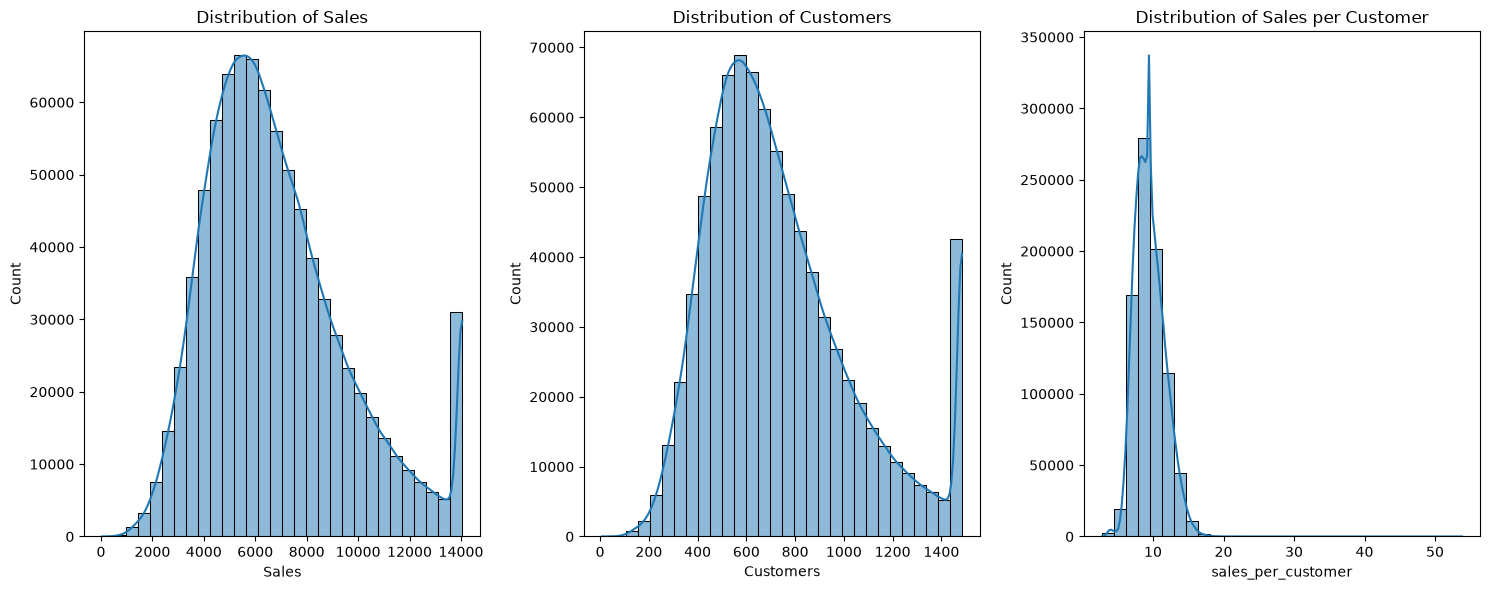

In [21]:
df_open = s_train[(s_train['Open'] !=0) & (s_train['Sales'] > 0)]

plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
sns.histplot(df_open['Sales'], bins=30, kde=True)
plt.title('Distribution of Sales')

plt.subplot(1, 3, 2)
sns.histplot(df_open['Customers'], bins=30, kde=True)
plt.title('Distribution of Customers')

plt.subplot(1, 3, 3)
sns.histplot(df_open['sales_per_customer'],bins=30,kde=True)
plt.title('Distribution of Sales per Customer')

plt.tight_layout()
plt.show()

#### **Insights:**
- Filters the DataFrame to include only open stores with positive sales, focusing on actual trading days.
- **Distribution of Sales:** The histogram shows a somewhat normal distribution but with a peak around 5000-8000 and a noticeable spike at the upper clipped limit (around 14000), indicating the effect of outlier handling.
- **Distribution of Customers:** Similar to sales, it shows a distribution skewed right with a peak around 500-800, and a spike at the upper clipped limit (around 1400), also reflecting outlier capping.
- **Distribution of Sales per Customer:** This distribution is highly right-skewed, with most values concentrated between 5 and 15, indicating that most transactions have a relatively low average sales value per customer.
- These plots provide initial insights into the central tendency, spread, and shape of these key performance indicators.

## *Categorical Column*

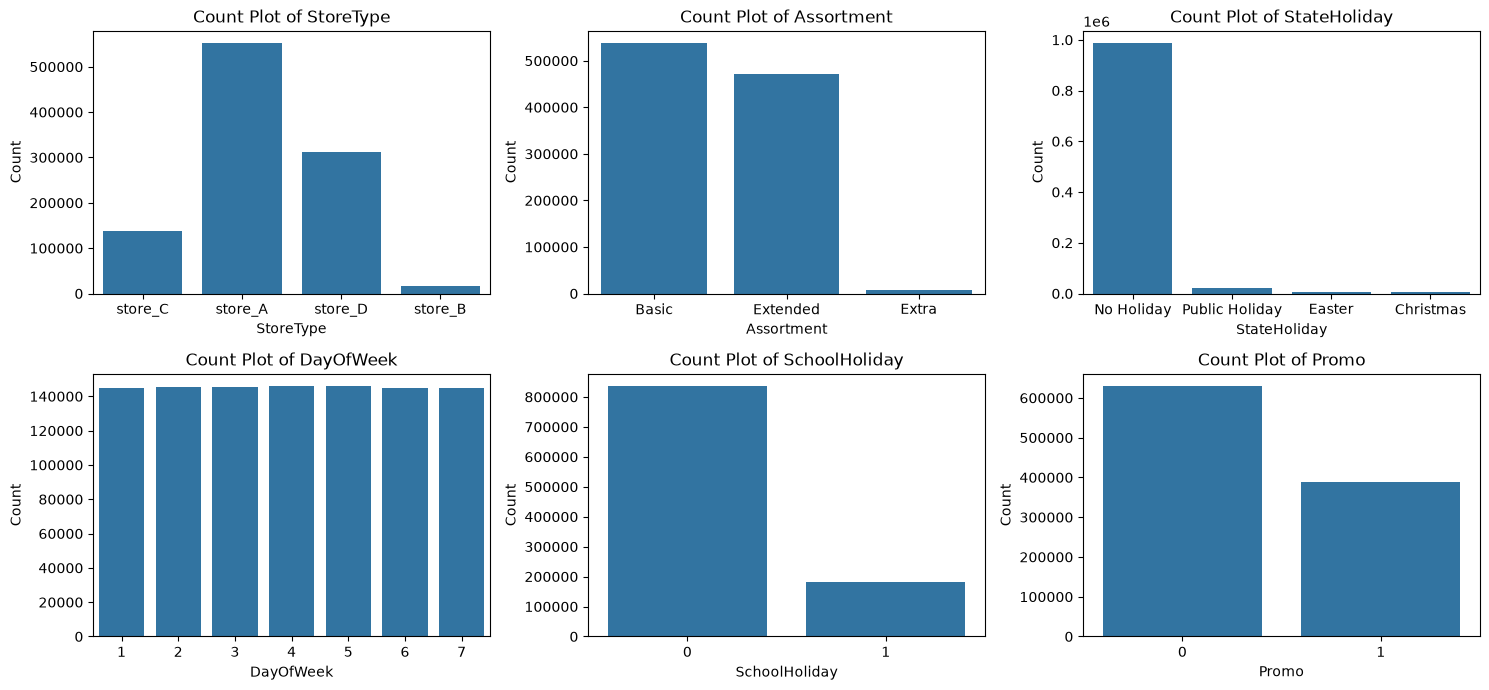

In [22]:
cat_col = ['StoreType', 'Assortment','StateHoliday', 'DayOfWeek','SchoolHoliday','Promo']

plt.figure(figsize=(15, 10))

for i, col in enumerate(cat_col, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=s_train, x=col)
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


#### **Insights:**
- Generates count plots for several categorical features.
- **StoreType:** 'store_A' and 'store_C' are the most frequent types, with 'store_B' being very rare.
- **Assortment:** 'Basic' and 'Extended' assortments are common, while 'Extra' is rare.
- **StateHoliday:** 'No Holiday' days overwhelmingly dominate, as expected, with other holidays being infrequent events.
- **DayOfWeek:** All days of the week have a fairly uniform distribution of occurrences.
- **SchoolHoliday:** Most days are not school holidays (0), indicating these are less frequent events.
- **Promo:** Days without promotions (0) are more frequent than days with promotions (1).
- These plots help understand the prevalence and balance of different categories within each feature, which is important for understanding potential biases and for encoding strategies.

## **Bivariate Analysis**

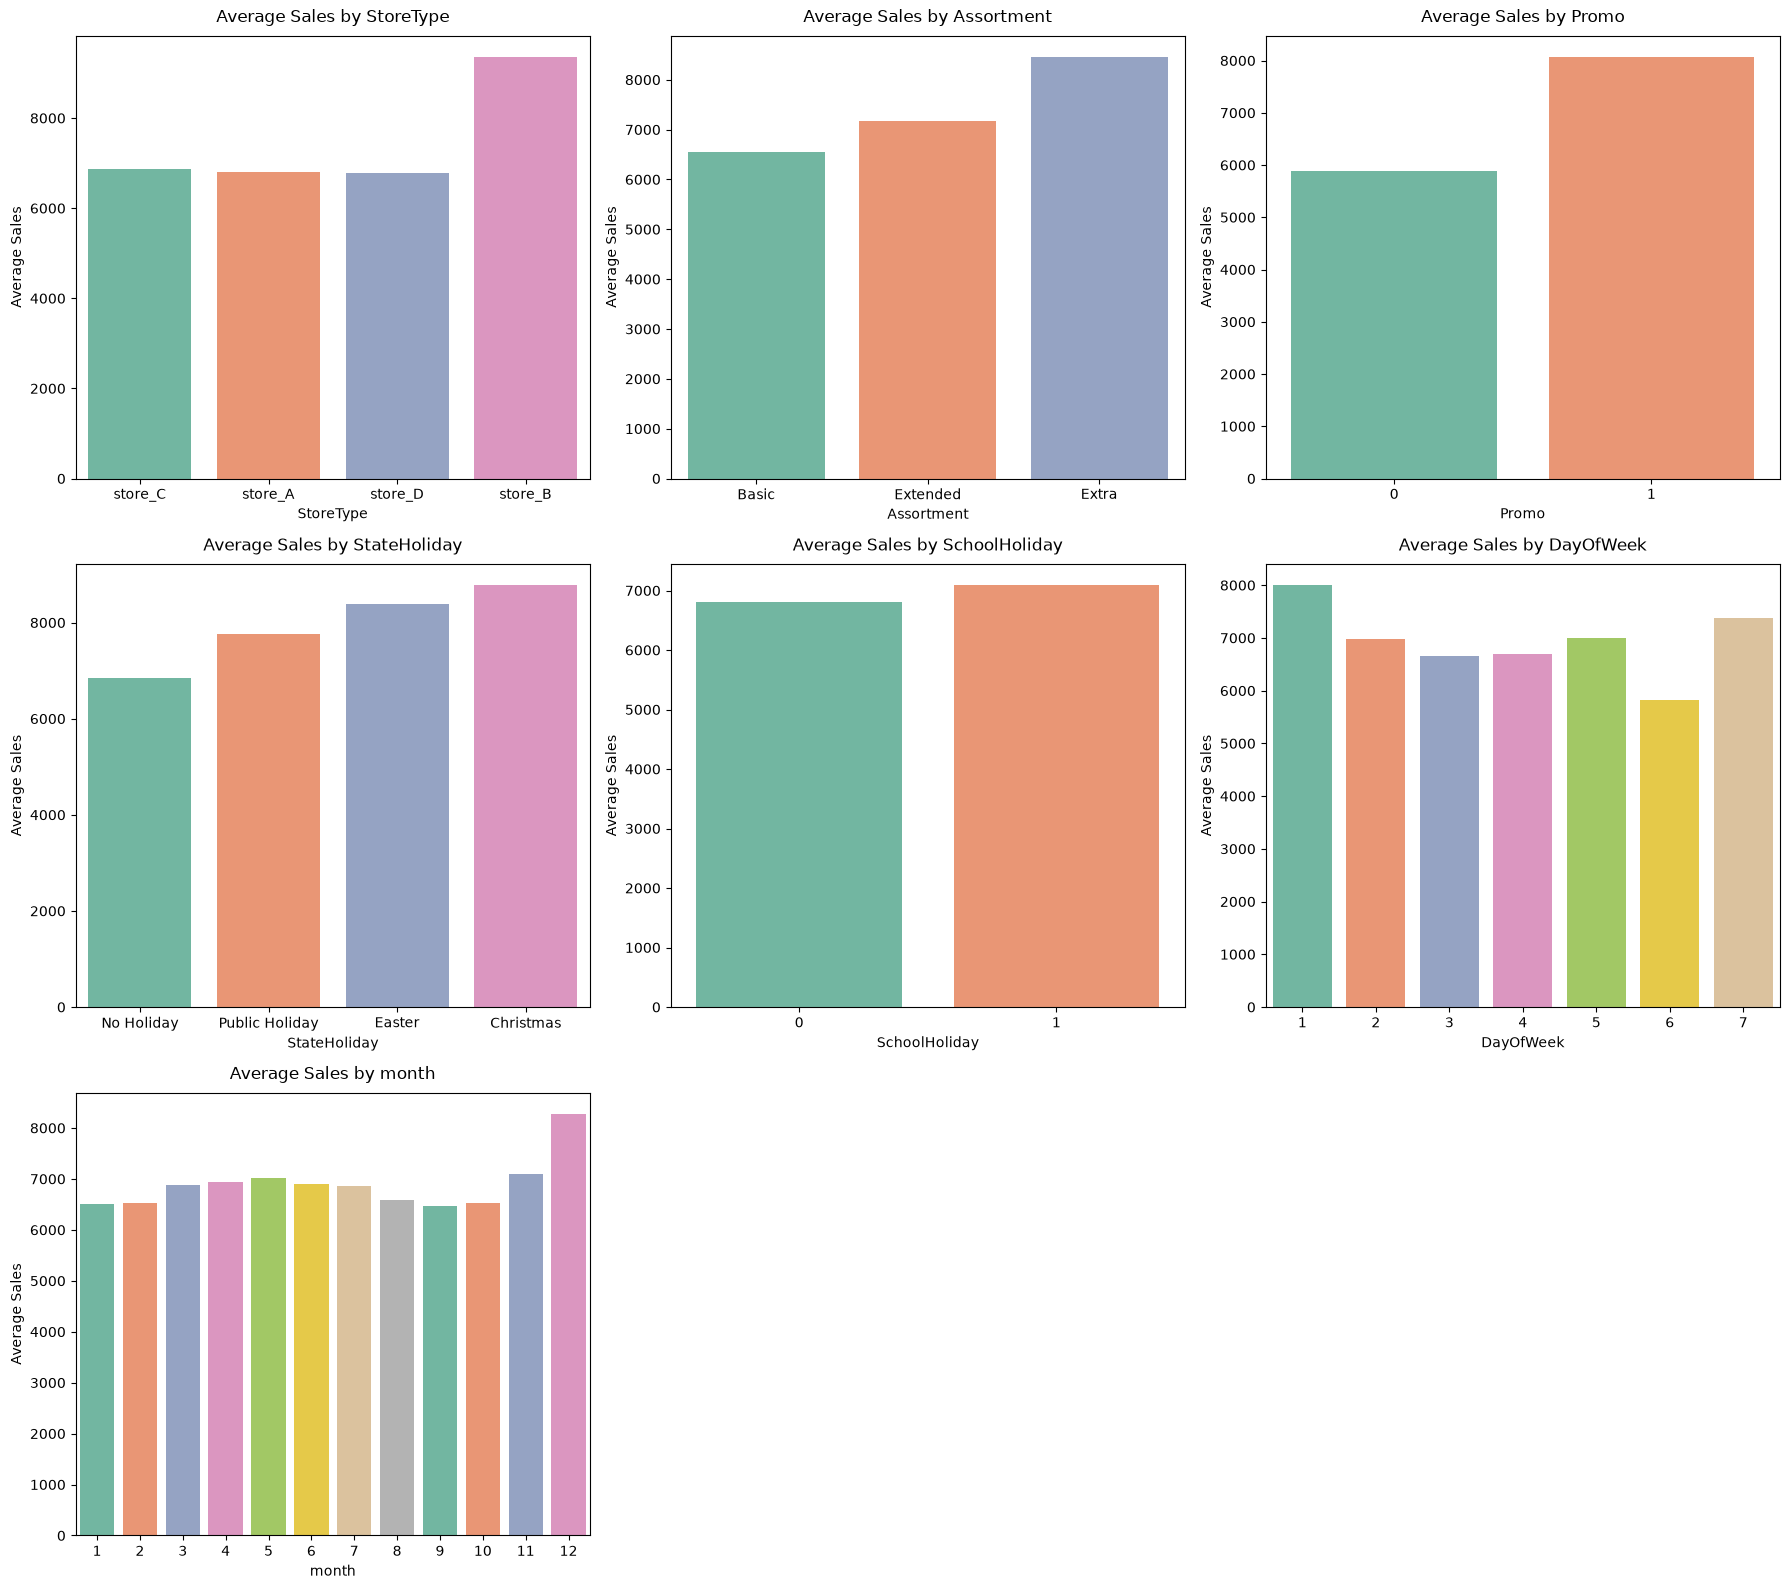

In [23]:
cat_features = ['StoreType', 'Assortment', 'Promo', 'StateHoliday', 'SchoolHoliday', 'DayOfWeek', 'month']

plt.figure(figsize=(18, 16))

for i, col in enumerate(cat_features, 1):
    plt.subplot(3, 3, i)

    sns.barplot(
        data=s_train[s_train['Open'] == 1],
        x=col,
        y='Sales',
        estimator='mean',
        errorbar=None,
        hue=col,
        legend=False,
        palette='Set2'
    )

    plt.title(f'Average Sales by {col}', pad=10)
    plt.xlabel(col)
    plt.ylabel('Average Sales')

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.tight_layout()
plt.show()

#### **Insights:**
- Plots average sales grouped by various categorical features, considering only open stores.
- **StoreType:** 'store_B' has significantly higher average sales, followed by 'store_D'.
- **Assortment:** 'Extra' assortment stores show the highest average sales.
- **Promo:** Stores with promotions ('Promo' = 1) have substantially higher average sales than those without.
- **StateHoliday:** 'Christmas' holidays show the highest average sales, followed by 'Easter' and 'Public Holiday', indicating these holidays drive sales.
- **SchoolHoliday:** Days with school holidays (1) tend to have slightly higher average sales.
- **DayOfWeek:** Day 7 (Sunday, if 1-indexed for Monday is 1, Sunday is 7) and Day 1 (Monday) often show higher sales, with a dip midweek.
- **Month:** December (12) consistently shows the highest average sales, likely due to holiday shopping.
- These insights are crucial for understanding which categorical factors significantly influence sales, guiding business decisions and feature importance for modeling.

## **Analysis of New Time-Based Feature**

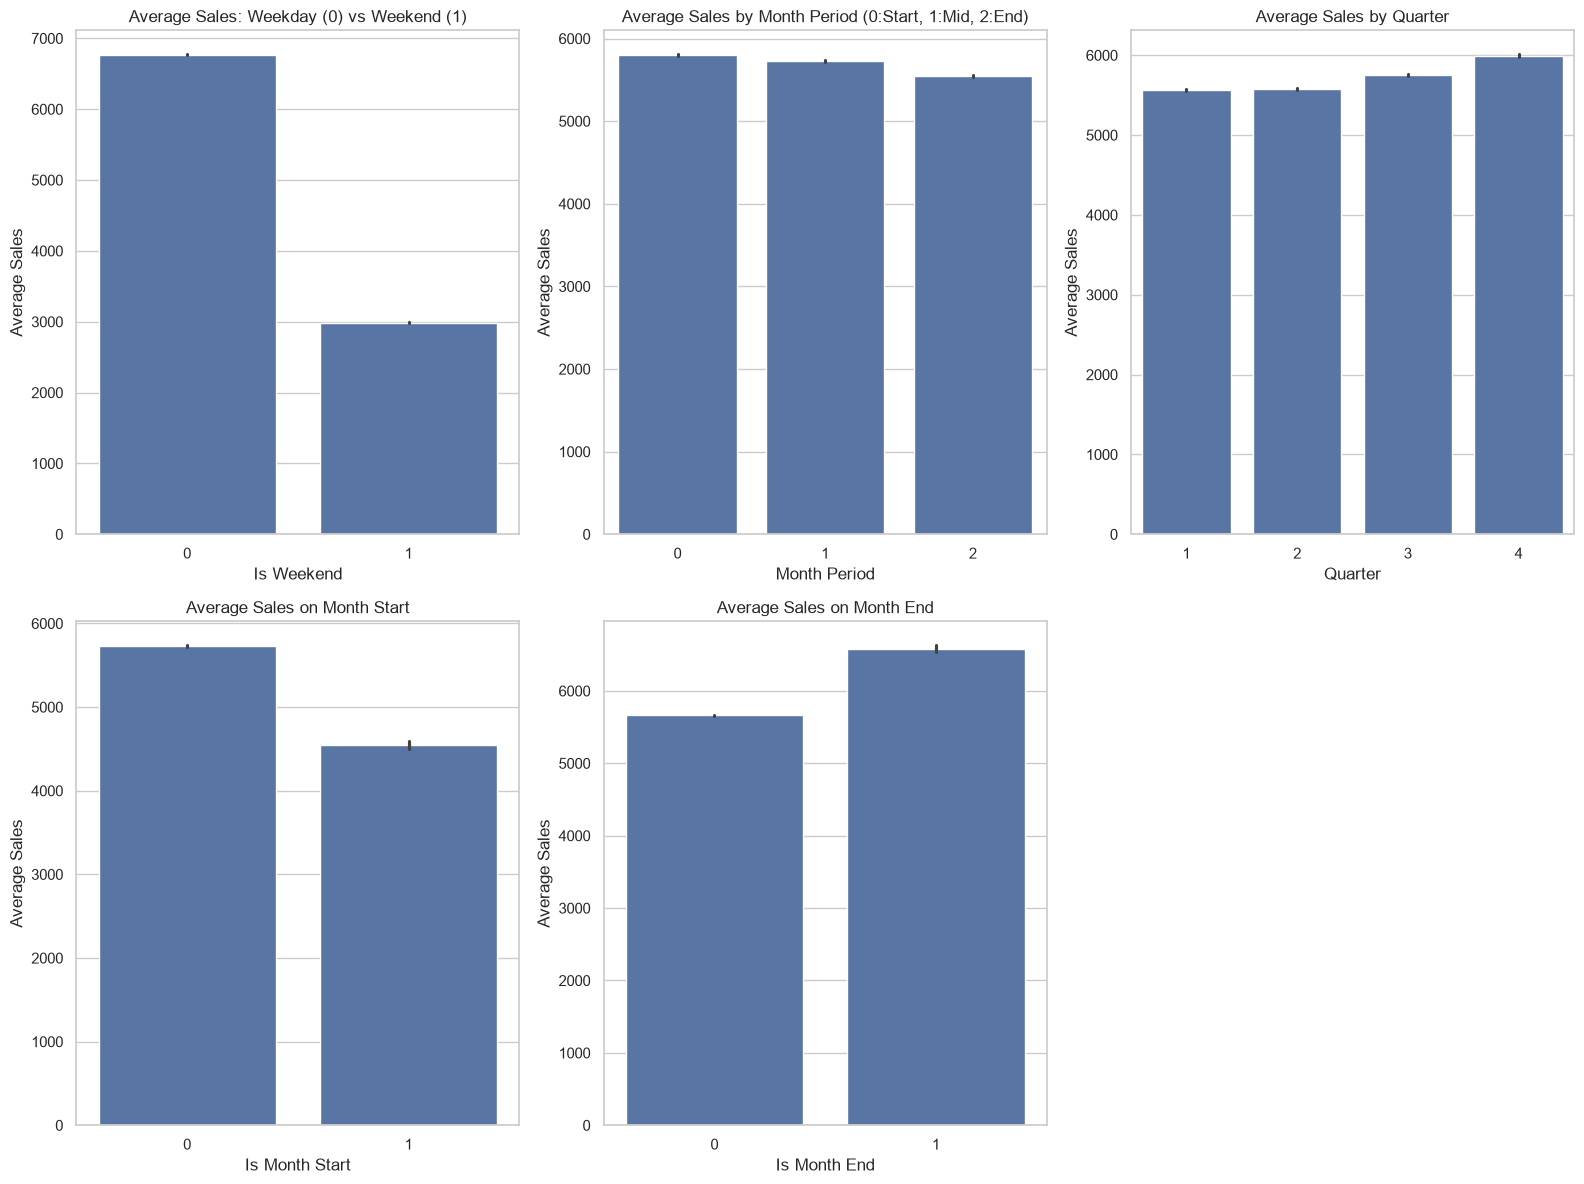

In [24]:
# Plot style setup
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# 1. Sales vs Weekend
plt.subplot(2, 3, 1)
sns.barplot(x="is_weekend", y="Sales", data=s_train, estimator=np.mean)
plt.title("Average Sales: Weekday (0) vs Weekend (1)")
plt.xlabel("Is Weekend")
plt.ylabel("Average Sales")

# 2. Sales vs Month Period
plt.subplot(2, 3, 2)
sns.barplot(x="month_period", y="Sales", data=s_train, estimator=np.mean)
plt.title("Average Sales by Month Period (0:Start, 1:Mid, 2:End)")
plt.xlabel("Month Period")
plt.ylabel("Average Sales")

# 3. Sales vs Quarter
plt.subplot(2, 3, 3)
sns.barplot(x="quarter", y="Sales", data=s_train, estimator=np.mean)
plt.title("Average Sales by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Average Sales")

# 4. Sales vs Month Start
plt.subplot(2, 3, 4)
sns.barplot(x="is_month_start", y="Sales", data=s_train, estimator=np.mean)
plt.title("Average Sales on Month Start")
plt.xlabel("Is Month Start")
plt.ylabel("Average Sales")

# 5. Sales vs Month End
plt.subplot(2, 3, 5)
sns.barplot(x="is_month_end", y="Sales", data=s_train, estimator=np.mean)
plt.title("Average Sales on Month End")
plt.xlabel("Is Month End")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

#### **Insights:**
- Analyzes the impact of newly engineered time-based features on average sales.
- **Average Sales: Weekday vs Weekend:** Weekdays (0) have significantly higher average sales than weekends (1). This is somewhat counter-intuitive for retail but could be specific to the type of stores (e.g., business-oriented stores).
- **Average Sales by Month Period:** Sales are relatively consistent across the month periods (start, mid, end), with a slight dip towards the end of the month.
- **Average Sales by Quarter:** Sales are fairly stable across quarters.
- **Average Sales on Month Start/End:** Month-end (1) shows slightly higher average sales compared to month-start (0).
- These plots provide specific insights into temporal patterns and help validate the usefulness of the engineered features.

### **Competitor Distance vs Sales**

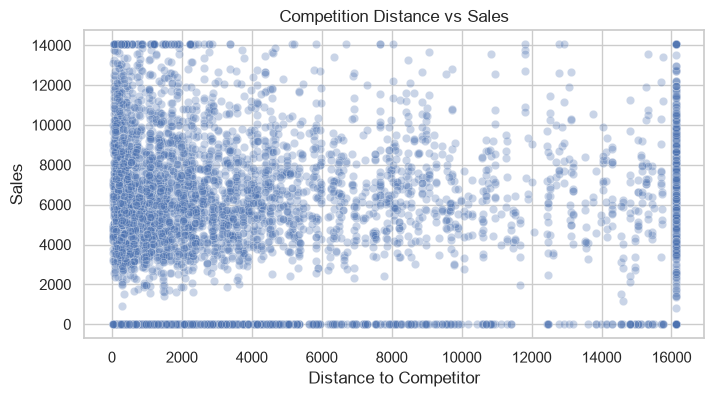

In [25]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=s_train.sample(5000, random_state=42), x='CompetitionDistance', y='Sales', alpha=0.3)
plt.title('Competition Distance vs Sales')
plt.xlabel('Distance to Competitor')
plt.ylabel('Sales')
plt.show()

#### **Insights:**
- Plots a scatter plot of `CompetitionDistance` against `Sales` using a sample of 5000 points for better visualization.
- The plot suggests a weak or no clear linear relationship between competition distance and sales.
- Sales seem to be high across various competition distances, and there's a cluster of high sales at very low competition distances as well as very high ones.
- This indicates that while competition distance might play a role, it's not a primary linear driver of sales on its own, or its effect is more complex and potentially influenced by other factors.

## **Multivariate Analysis**

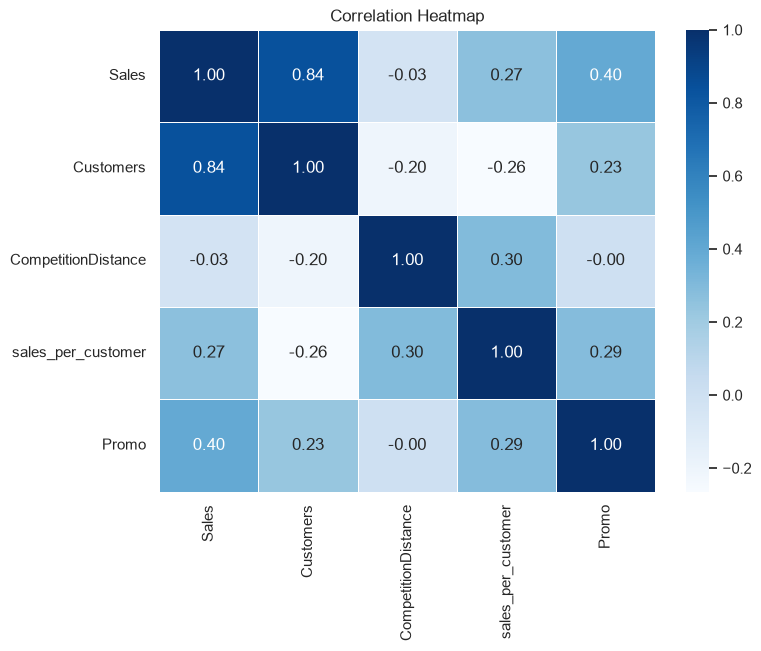

In [26]:
plt.figure(figsize=(8, 6))

num_cols = ['Sales', 'Customers', 'CompetitionDistance', 'sales_per_customer', 'Promo']
corr_matrix = s_train[s_train['Open'] == 1][num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

#### **Insights:**
- Computes and visualizes the Pearson correlation matrix for selected numerical columns (`Sales`, `Customers`, `CompetitionDistance`, `sales_per_customer`, `Promo`) from open stores.
- **Key Observations:**
    - `Sales` and `Customers` are highly positively correlated (0.84), which is expected as more customers generally lead to more sales.
    - `Sales` has a moderate positive correlation with `Promo` (0.40), indicating that promotions significantly boost sales.
    - `Sales_per_customer` has a positive correlation with `Sales` (0.27) and `Promo` (0.29), suggesting that promotions might also increase the average value per customer or transaction.
    - `CompetitionDistance` shows very low correlations with `Sales` (-0.03) and `Customers` (-0.20), supporting the scatter plot's observation that it's not a strong linear predictor of sales or customer count.
- This heatmap is vital for understanding linear relationships between variables and identifying potential multicollinearity or strong predictors.

### **Promo Distribution Across Train and Test Sets**

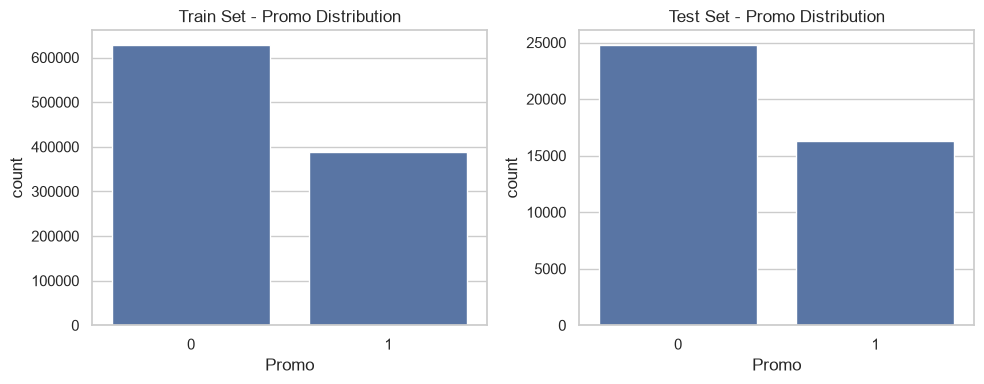

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x='Promo', data= s_train, ax=axes[0])
axes[0].set_title('Train Set - Promo Distribution')

sns.countplot(x='Promo', data=s_test, ax=axes[1])
axes[1].set_title('Test Set - Promo Distribution')

plt.tight_layout()
plt.show()

#### **Insights:**
- Compares the distribution of the `Promo` feature between the training (`s_train`) and testing (`s_test`) datasets.
- **Observation:** Both the training and test sets show a similar pattern: there are more instances where `Promo` is 0 (no promotion) than when `Promo` is 1 (promotion is active).
- This similarity in distribution is important as it suggests that the test set's promotional conditions are representative of the training set's, which is good for model generalization. If distributions were vastly different, it could indicate potential issues with model performance on unseen data.

### **Feature Dropping**

In [28]:
s_train = s_train.drop(columns=['Date'])
s_train = s_train.drop(columns=['Customers','sales_per_customer'])
s_train = s_train.drop(columns=['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'])
s_train = s_train.drop(columns=['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear'])
s_train = s_train.drop(columns=['day_of_week'])



#### **Insights:**
- This cell drops several features from the `s_train` DataFrame.
- **Reasoning for dropping (in general):**
    - `Date`: While these were used to derive other features, the original columns might be dropped if more granular or transformed versions.
    - `Customers`, `sales_per_customer`: `Customers` is highly correlated with `Sales` (the target variable), and `sales_per_customer` is derived from it. They might be dropped to prevent data leakage if these are not available at prediction time, or if the model should predict `Sales` directly without customer count as input.
    - `Promo2SinceWeek`, `Promo2SinceYear`, `PromoInterval`: These were likely consolidated into `Is_Promo2_Active` or might be considered redundant / too noisy after other promo-related features were created.
    - `CompetitionOpenSinceMonth`, `CompetitionOpenSinceYear`: These were likely used to create `CompetitionOpenMonths` and are dropped to avoid redundancy.
    - `day_of_week`: This feature was also dropped, potentially because other time-based features (like `is_weekend`, `month_period`, `is_month_start`, `is_month_end`, `quarter`) already capture sufficient temporal information, or to simplify the model by removing redundant or less impactful features.
- Feature dropping reduces dimensionality, removes redundant or highly correlated features, and can sometimes improve model performance and interpretability.

### **Feature Encoding**

In [29]:
cat_col = ['StoreType', 'Assortment','StateHoliday']
s_train = pd.get_dummies(s_train, columns=cat_col, drop_first=True,dtype=int)

#### **Insights:**
- Applies one-hot encoding to specified categorical columns (`StoreType`, `Assortment`, `StateHoliday`) using `pd.get_dummies()`.
- `drop_first=True` is used to prevent multicollinearity by dropping the first category for each feature. For example, if `StoreType` had 'store_A', 'store_B', 'store_C', 'store_D', it would create columns like `StoreType_store_B`, `StoreType_store_C`, `StoreType_store_D`, with 'store_A' being the reference (all zeros).
- `dtype=int` ensures the new dummy columns are integers (0 or 1) instead of boolean or float.
- This step converts categorical data into a numerical format that machine learning models can process.

In [30]:
s_train['Sales'] = s_train['Sales'].astype(int)


#### **Insights:**
- Converts the `Sales` column to an integer data type.
- This is a good practice for target variables that represent counts or monetary values, as it ensures consistency and might slightly reduce memory usage if the values were previously floats without fractional parts.

In [31]:
s_train.head()

,Store,DayOfWeek,Sales,Open,Promo,SchoolHoliday,CompetitionDistance,Promo2,year,month,...,is_month_end,quarter,StoreType_store_B,StoreType_store_C,StoreType_store_D,Assortment_Extended,Assortment_Extra,StateHoliday_Easter,StateHoliday_No Holiday,StateHoliday_Public Holiday
0,1,5,5263,1,1,1,1270.0,0,2015,7,...,1,3,0,1,0,0,0,0,1,0
1,2,5,6064,1,1,1,570.0,1,2015,7,...,1,3,0,0,0,0,0,0,1,0
2,3,5,8314,1,1,1,14130.0,1,2015,7,...,1,3,0,0,0,0,0,0,1,0
3,4,5,13995,1,1,1,620.0,0,2015,7,...,1,3,0,1,0,1,0,0,1,0
4,5,5,4822,1,1,1,16135.0,0,2015,7,...,1,3,0,0,0,0,0,0,1,0


#### **Insights:**
- Displays the first 5 rows of the `s_train` DataFrame after all preprocessing, feature engineering, feature dropping, and encoding steps.
- This provides a final look at the transformed dataset's structure.
- **Key Observations:**
    - Original categorical columns (`StoreType`, `Assortment`, `StateHoliday`) have been replaced by new one-hot encoded binary columns (e.g., `StoreType_store_B`, `Assortment_Extended`, `StateHoliday_No Holiday`).
    - Engineered features like `Is_Promo2_Active`, `CompetitionOpenMonths`, `is_weekend` are present.
    - Dropped columns are no longer visible.
- This confirms that the data is now in a suitable format for machine learning model training.

In [32]:
s_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 26 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Store                        1017209 non-null  int64  
 1   DayOfWeek                    1017209 non-null  int64  
 2   Sales                        1017209 non-null  int64  
 3   Open                         1017209 non-null  int64  
 4   Promo                        1017209 non-null  int64  
 5   SchoolHoliday                1017209 non-null  int64  
 6   CompetitionDistance          1017209 non-null  float64
 7   Promo2                       1017209 non-null  int64  
 8   year                         1017209 non-null  int32  
 9   month                        1017209 non-null  int32  
 10  day                          1017209 non-null  int32  
 11  Is_Promo2_Active             1017209 non-null  int64  
 12  CompetitionOpenMonths        1017209 non-null  int64 

#### **Insights:**
- Provides a summary of the `s_train` DataFrame after all transformations.
- **Key Observations:**
    - The number of columns has changed (increased due to one-hot encoding, decreased due to dropping).
    - All columns are now numerical (`int64`, `int32`, `float64`), making the dataset ready for most machine learning algorithms.
    - No null values are present.
    - Memory usage is displayed, which can be useful for performance considerations.
- This check confirms that the data types are correct and the DataFrame is clean and ready for modeling.

In [33]:
logger.info("Complete Encoding for train dataset")

2026-09-14 15:37:11,010 - INFO - Complete Encoding for train dataset


#### **Insights:**
- This log statement confirms that the encoding process for the training dataset is complete.
- It's a critical milestone, indicating that the data is now fully prepared in a numerical format suitable for model training.

# **Saving Dataset to CSV**

In [34]:
s_train.to_csv('clean_store_train.csv', index=False)
logger.info("Saving clean_store_train dataset to CSV Successfully")

2026-09-14 15:37:17,513 - INFO - Saving clean_store_train dataset to CSV Successfully


#### **Insights:**
- Saves the fully preprocessed and engineered `s_train` DataFrame to a new CSV file named 'clean_store_train.csv'.
- `index=False` prevents pandas from writing the DataFrame index as a column in the CSV file.
- This step is important for persisting the cleaned data, allowing it to be easily loaded and used for subsequent modeling tasks without repeating all the preprocessing steps.
- The logger message confirms the successful saving operation.

# **Download Files**

In [35]:
# files.download('clean_store_train.csv')
# logger.info("Download clean_store_train files Successfully")

#### **Insights:**
- Uses `files.download()` from `google.colab` to download the 'clean_store_train.csv' file to the user's local machine.
- This is useful for users who want to access the processed data outside of the Colab environment or for local backup.
- The logger message confirms the successful download operation.